# Load Dataset

#### Dataset Information


In [1]:
import pandas as pd

df = pd.read_csv("titanic.csv")

print(df.head())
print(df.shape)
print(df.info())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
(8

## Data Cleaning
## Handle Missing Values

In [2]:
# Fill Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Cabin has too many missing values, drop it
df.drop('Cabin', axis=1, inplace=True)

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


#### Survival Analysis
#### Who survived more: Males or Females?

In [4]:
survival_gender = df.groupby('Sex')['Survived'].mean()*100
print(survival_gender)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


#### Did Passenger Class Affect Survival

In [5]:
survival_class = df.groupby('Pclass')['Survived'].mean()*100
print(survival_class)

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


#### Survival Rate by Age Group

In [10]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_survival = df.groupby('AgeGroup', observed=False)['Survived'].mean() * 100

print(age_survival)

AgeGroup
Child          57.971014
Teen           42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64


#### Data Visualization

#### Survival by Gender

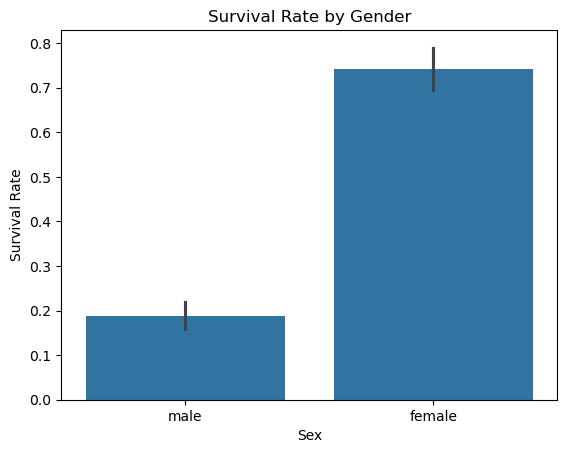

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Sex', y='Survived', data=df)

plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.show()

#### Age Distribution Histogram

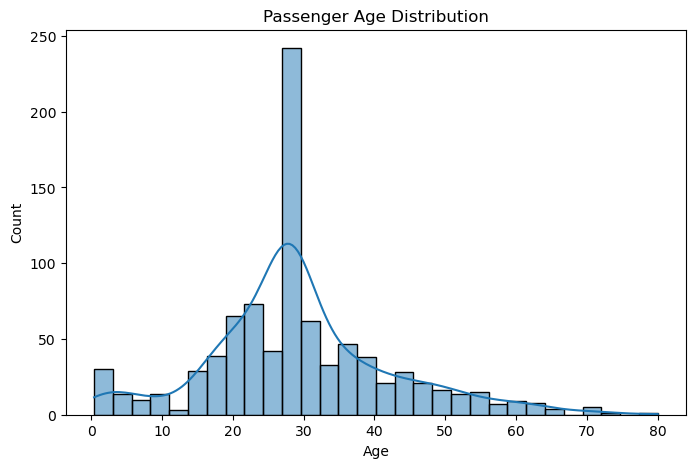

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()